# Capstone Project: Data Cleaning and Preprocessing

The objective is to:

1. Preview available datasets
2. Clean and preprocess the datasets

## Dataset Choices:

 **Dataset 1: OpenStreetMap Road Networks**

Extracted using the `osmdata` R package  
Vector data representing road infrastructure, including highways, primary, secondary, and tertiary roads  

 **Dataset 2: Kenya High Resolution Population Density**

Raster dataset providing population distribution at fine spatial resolution  

 **Dataset 3: JRC Global River Flood Hazard (Option 1):**

Raster dataset from the Joint Research Centre representing flood hazard probabilities  

 **Dataset 4: (Option 2): Microsoft’s AI for Good Flood Change**

This dataset is derived from **Sentinel-1 Synthetic Aperture Radar (SAR) imagery** processed using a deep learning change detection model developed by Microsoft’s AI for Good Research Lab. It spans a ten-year period (October 2014 – September 2024) and is designed to support global flood monitoring, disaster response, and trend analysis. \[Dataset Repository: https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/tree/main/S03/S03E036]
More details about the data: https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/blob/main/README.md

**Point-Level Detection Records**

The **Point-Level Detection Records** represent the most granular component of the dataset, capturing individual flood detection events at pixel level. Each record corresponds to a location identified as flooded by the model, which compares pre- and post-event SAR images to detect changes in surface water presence. This approach ensures accurate detection even under cloud cover and during nighttime conditions.

These records are stored in **Parquet format**, optimized for large-scale geospatial data handling. Each entry includes:


**Data Description**  
**Parquet File Schema**

| Column                      | Type  | Description                    | Example Value            |
| --------------------------- | ----- | ------------------------------ | ------------------------ |
| year                        | int   | Year of observation            | 2023                     |
| month                       | int   | Month of observation           | 7                        |
| day                         | int   | Day of observation             | 15                       |
| lat                         | float | Latitude of detection          | 27.842                   |
| lon                         | float | Longitude of detection         | 30.156                   |
| filename                    | str   | Sentinel-1 source file         | 'S1A\_IW\_GRDH\_1SDV...' |
| land\_cover                 | int   | ESA WorldCover class           | 40                       |
| dem\_metric\_1              | float | Pixel slope                    | 2.5                      |
| dem\_metric\_2              | float | Max slope within 240m          | 5.8                      |
| soil\_moisture              | float | LPRM soil moisture %           | 35.7                     |
| soil\_moisture\_zscore      | float | Moisture anomaly               | 2.3                      |
| soil\_moisture\_sca         | float | SCA soil moisture %            | 38.2                     |
| soil\_moisture\_sca\_zscore | float | SCA moisture anomaly           | 2.1                      |
| temp                        | float | Avg daily min temp °C          | 22.4                     |
| edge\_false\_positives      | int   | Edge effect flag (0=no, 1=yes) | 0                        |

**Land Cover Classes**  
Common values in the `land_cover` column:

*   10: Tree cover
*   20: Shrubland
*   30: Grassland
*   40: Cropland
*   50: Urban/built-up
*   60: Bare ground (typically excluded)
*   70: Snow/Ice
*   80: Permanent Water bodies (excluded in this dataset)
*   90: Wetland


In [5]:
# 1. SETUP & LIBRARIES

# Load the required packages
library(sf)          # Simple Features - a standardized way to encode spatial vector data
library(ggplot2)     # Data visualization package
library(dplyr)       # Data manipulation package
library(terra)       # Spatial data manipulation and analysis
library(tidyterra)   # Integration of terra with the tidyverse
library(knitr)       # For nice table output

setwd("/home/user/course-2-data-stewardship/module-7/pset-student/CRUM_Nairobi/data")
getwd()

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




terra 1.8.60




Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter





Attaching package: ‘knitr’




The following object is masked from ‘package:terra’:

    spin




[1] "/home/user/course-2-data-stewardship/module-7/pset-student/CRUM_Nairobi/data"

Reading layer `gadm41_KEN_1' from data source 
  `/home/user/course-2-data-stewardship/module-7/pset-student/CRUM_Nairobi/data/processed_data/gadm41_KEN_1.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 47 features and 11 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 33.90959 ymin: -4.720417 xmax: 41.92622 ymax: 5.061166
Geodetic CRS:  WGS 84


[1] "Area of Interest defined:"


     xmin      ymin      xmax      ymax 
36.663475 -1.442159 37.103703 -1.157910 


Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<MULTIPOLYGON [°]>
1,KEN.30_1,KEN,Kenya,Nairobi,NA,NA,County,County,47,KE.NB,NA,MULTIPOLYGON (((36.89265 -1...


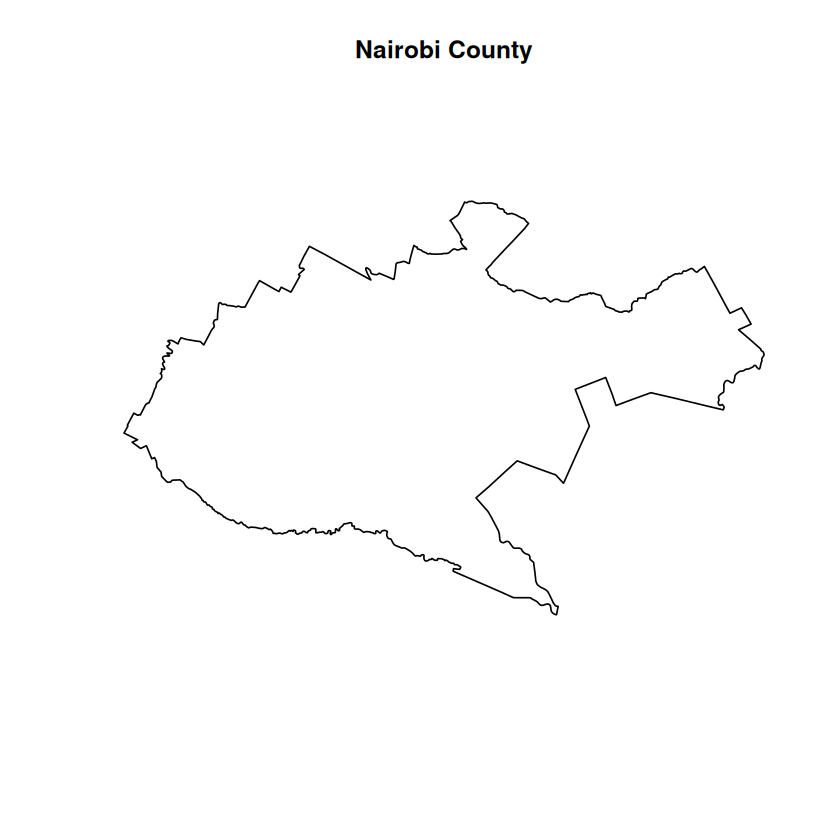

In [4]:
# LOAD AREA OF INTEREST - NAIROBI COUNTY
# Load Nairobi Shapefile from previously downloaded data
ken_l1 <- st_read("processed_data/gadm41_KEN_1.shp")

# Filter Nairobi
nairobi_gadm <- ken_l1 %>% filter(NAME_1 == "Nairobi")

# Use Narobi GADM boundary as AOI
aoi <- nairobi_gadm

# Check and print AOI
print("Area of Interest defined:")
print(st_bbox(aoi))
plot(st_geometry(aoi), main = "Nairobi County")

#See columns and rows 
head(nairobi_gadm)

Reading layer `roads_clean' from data source 
  `/home/user/course-2-data-stewardship/module-7/pset-student/CRUM_Nairobi/data/processed_data/nairobi_roads_clean.gpkg' 
  using driver `GPKG'
Simple feature collection with 25898 features and 8 fields
Geometry type: MULTILINESTRING
Dimension:     XY
Bounding box:  xmin: 36.65601 ymin: -1.441433 xmax: 37.10801 ymax: -1.155555
Geodetic CRS:  WGS 84


Simple feature collection with 6 features and 8 fields
Geometry type: MULTILINESTRING
Dimension:     XY
Bounding box:  xmin: 36.80254 ymin: -1.348233 xmax: 36.91442 ymax: -1.286476
Geodetic CRS:  WGS 84
   osm_id               name   highway surface lanes maxspeed road_class
1 4685092 Airport South Road secondary asphalt     2     <NA>   Arterial
2 4716860 State House Avenue secondary asphalt     2     <NA>   Arterial
3 4716861   Processional Way  tertiary asphalt     2     <NA>  Collector
4 4716862    Kenyatta Avenue secondary asphalt     2       50   Arterial
5 4716873               <NA> secondary asphalt     2     <NA>   Arterial
6 4716887    Kenyatta Avenue secondary asphalt     2       50   Arterial
    length_m                           geom
1 1176.13321 MULTILINESTRING ((36.91442 ...
2  902.33903 MULTILINESTRING ((36.80434 ...
3  133.49528 MULTILINESTRING ((36.81367 ...
4  166.29080 MULTILINESTRING ((36.81026 ...
5   24.16654 MULTILINESTRING ((36.80254 ...
6  172.65746 MULTILINE

Rows: 2,544
Columns: 9
$ osm_id     <chr> "4685092", "4716860", "4716861", "4716862", "4716873", "471…
$ name       <chr> "Airport South Road", "State House Avenue", "Processional W…
$ highway    <chr> "secondary", "secondary", "tertiary", "secondary", "seconda…
$ surface    <chr> "asphalt", "asphalt", "asphalt", "asphalt", "asphalt", "asp…
$ lanes      <dbl> 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2,…
$ maxspeed   <chr> NA, NA, NA, "50", NA, "50", "50", "50", NA, "50", "50", NA,…
$ road_class <chr> "Arterial", "Arterial", "Collector", "Arterial", "Arterial"…
$ length_m   <dbl> 1176.13321, 902.33903, 133.49528, 166.29080, 24.16654, 172.…
$ geom       <MULTILINESTRING [°]> MULTILINESTRING ((36.91442 ..., MULTILINEST…


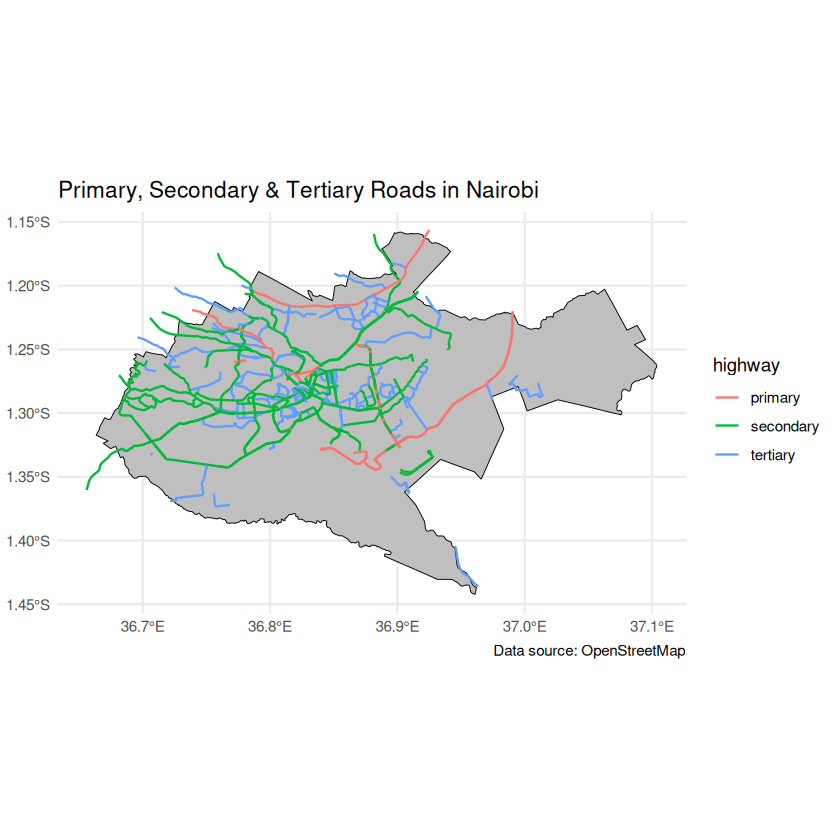

In [40]:
#DATASET 1: OPENSTREETMAP ROAD NETWORKS
# Load the roads data from previously downloaded data
roads <- st_read("processed_data/nairobi_roads_clean.gpkg") %>% 
  filter(highway %in% c("primary", "secondary", "tertiary"))
print(head(roads))
glimpse(roads)

# Plot the roads data
(roads_map <- ggplot() +
  geom_sf(data = nairobi_gadm, fill = "grey75", color = "black") +
  geom_sf(data = roads, aes(color = highway), size = 0.1) +
  theme_minimal() +
  labs(title = "Primary, Secondary & Tertiary Roads in Nairobi",
       caption = "Data source: OpenStreetMap"))

In [41]:
# DATASET 2: HIGH RESOLUTION POPULATION DENSITY

# Load the population data from previously downloaded data
pop <- terra::rast("processed_data/nairobi_population_density.tif") 
pop_crs <- crs(pop)
cat("Pop CRS:\n", st_crs(pop)$input, "\n\n")
print(pop)


Pop CRS:
 WGS 84 



class       : SpatRaster 
size        : 1023, 1585, 1  (nrow, ncol, nlyr)
resolution  : 0.0002777778, 0.0002777778  (x, y)
extent      : 36.66347, 37.10375, -1.442083, -1.157917  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : nairobi_population_density.tif 
name        : ken_general_2020 
min value   :         0.419219 
max value   :       400.607544 


In [42]:
# Check CRS compatibility
cat("Boundary CRS:\n", st_crs(nairobi_gadm)$input, "\n\n")
cat("Roads CRS:\n", st_crs(roads)$input, "\n\n")

Boundary CRS:
 WGS 84 



Roads CRS:
 WGS 84 



<SpatRaster> resampled to 501289 cells.


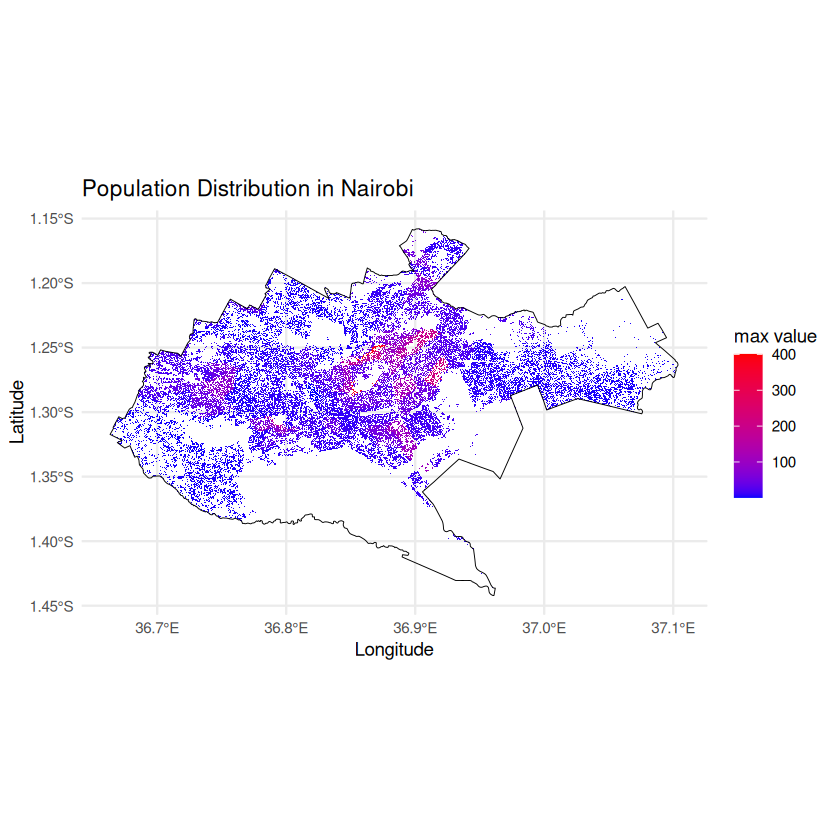

In [46]:
# Plot population distribution in Nairobi using ggplot
ggplot() +
  # Add the raster layer directly
  geom_spatraster(data = pop) +
  # Add region boundaries with black outlines
  geom_sf(data = nairobi_gadm, fill = NA, color = "black", size = 0.5) +
  # Add a color scale for population values - blue to red
  scale_fill_gradient(name = "max value", 
                      low = "blue", 
                      high = "red", 
                      na.value = "transparent") +
  # Add labels and title
  labs(
    title = "Population Distribution in Nairobi",
    x = "Longitude",
    y = "Latitude"
  ) +
  # Use a clean theme
  theme_minimal() +
  # Ensure the map uses the correct aspect ratio
  coord_sf()

Pop CRS:
 WGS 84 



class       : SpatRaster 
size        : 11999, 11999, 1  (nrow, ncol, nlyr)
resolution  : 0.0008333333, 0.0008333333  (x, y)
extent      : 29.98208, 39.98125, -9.991267, 0.0079  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : ID150_N0_E30_RP10_depth.tif 
name        : ID150_N0_E30_RP10_depth 


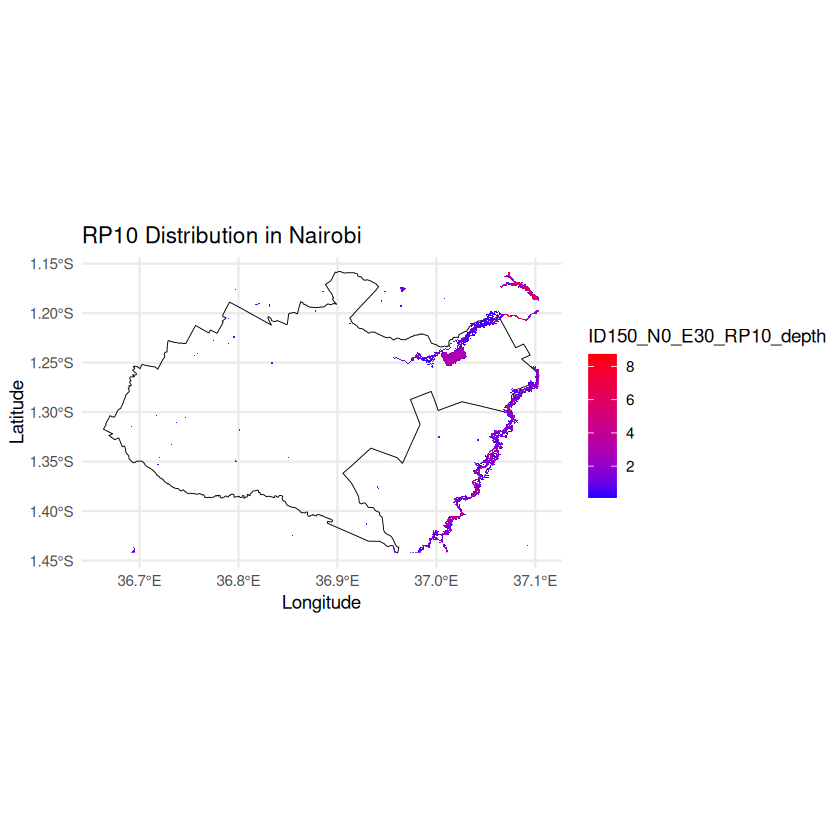

In [5]:
# DATASET 3: JRC GLOBAL RIVER FLOOD HAZARD
#10 M

# Load the population data from previously downloaded data
RP10 <- terra::rast("processed_data/RP10/ID150_N0_E30_RP10_depth.tif") 
RP10_crs <- crs(RP10)
cat("Pop CRS:\n", st_crs(RP10)$input, "\n\n")
print(RP10)

# Clip flood hazard data to AOI
RP10_clip <- crop(RP10, nairobi_gadm)


# Plot population distribution in Nairobi using ggplot
ggplot() +
  # Add region boundaries with black outlines
  geom_sf(data = nairobi_gadm, fill = NA, color = "black", size = 0.5) +
  # Add the raster layer directly
  geom_spatraster(data = RP10_clip) +  
  # Add a color scale for population values - blue to red
  scale_fill_gradient(name = "ID150_N0_E30_RP10_depth", 
                      low = "blue", 
                      high = "red", 
                      na.value = "transparent") +
  # Add labels and title
  labs(
    title = "RP10 Distribution in Nairobi",
    x = "Longitude",
    y = "Latitude"
  ) +
  # Use a clean theme
  theme_minimal() +
  # Ensure the map uses the correct aspect ratio
  coord_sf()


Pop CRS:
 WGS 84 



class       : SpatRaster 
size        : 11999, 11999, 1  (nrow, ncol, nlyr)
resolution  : 0.0008333333, 0.0008333333  (x, y)
extent      : 29.98208, 39.98125, -9.991267, 0.0079  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : ID150_N0_E30_RP100_depth.tif 
name        : ID150_N0_E30_RP100_depth 


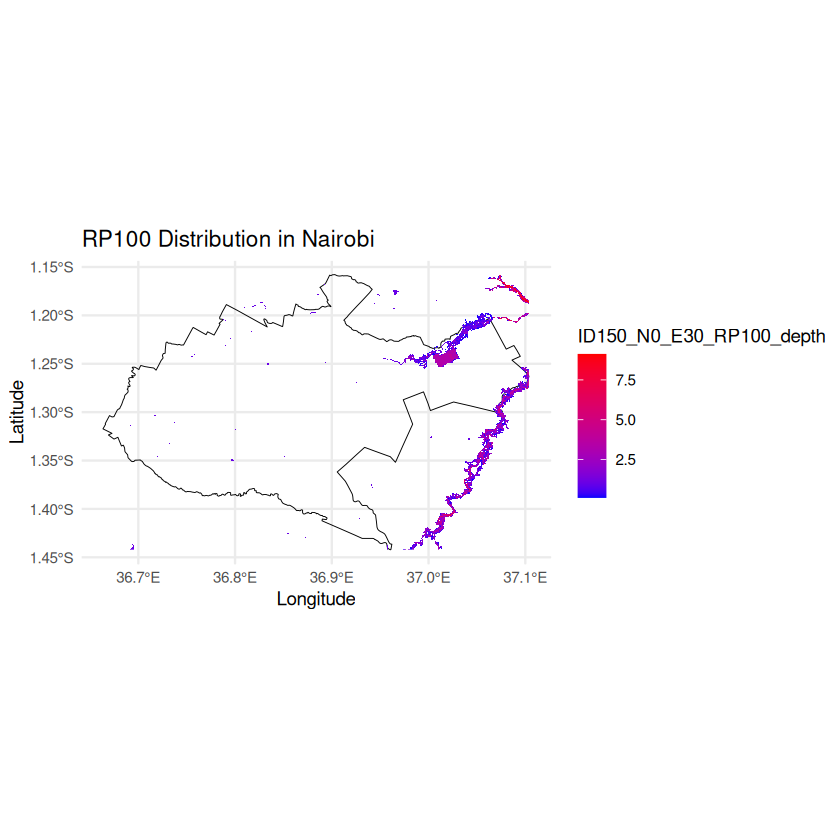

In [9]:
# DATASET 3: JRC GLOBAL RIVER FLOOD HAZARD
#100 M

# Load the population data from previously downloaded data
RP100 <- terra::rast("processed_data/RP100/ID150_N0_E30_RP100_depth.tif") 
RP100_crs <- crs(RP100)
cat("Pop CRS:\n", st_crs(RP10)$input, "\n\n")
print(RP100)

# Clip flood hazard data to AOI
RP100_clip <- crop(RP100, nairobi_gadm)


# Plot population distribution in Nairobi using ggplot
ggplot() +
  # Add region boundaries with black outlines
  geom_sf(data = nairobi_gadm, fill = NA, color = "black", size = 0.5) +
  # Add the raster layer directly
  geom_spatraster(data = RP100_clip) +  
  # Add a color scale for population values - blue to red
  scale_fill_gradient(name = "ID150_N0_E30_RP100_depth", 
                      low = "blue", 
                      high = "red", 
                      na.value = "transparent") +
  # Add labels and title
  labs(
    title = "RP100 Distribution in Nairobi",
    x = "Longitude",
    y = "Latitude"
  ) +
  # Use a clean theme
  theme_minimal() +
  # Ensure the map uses the correct aspect ratio
  coord_sf()

Pop CRS:
 WGS 84 



class       : SpatRaster 
size        : 11999, 11999, 1  (nrow, ncol, nlyr)
resolution  : 0.0008333333, 0.0008333333  (x, y)
extent      : 29.98208, 39.98125, -9.991267, 0.0079  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : ID150_N0_E30_RP500_depth.tif 
name        : ID150_N0_E30_RP500_depth 


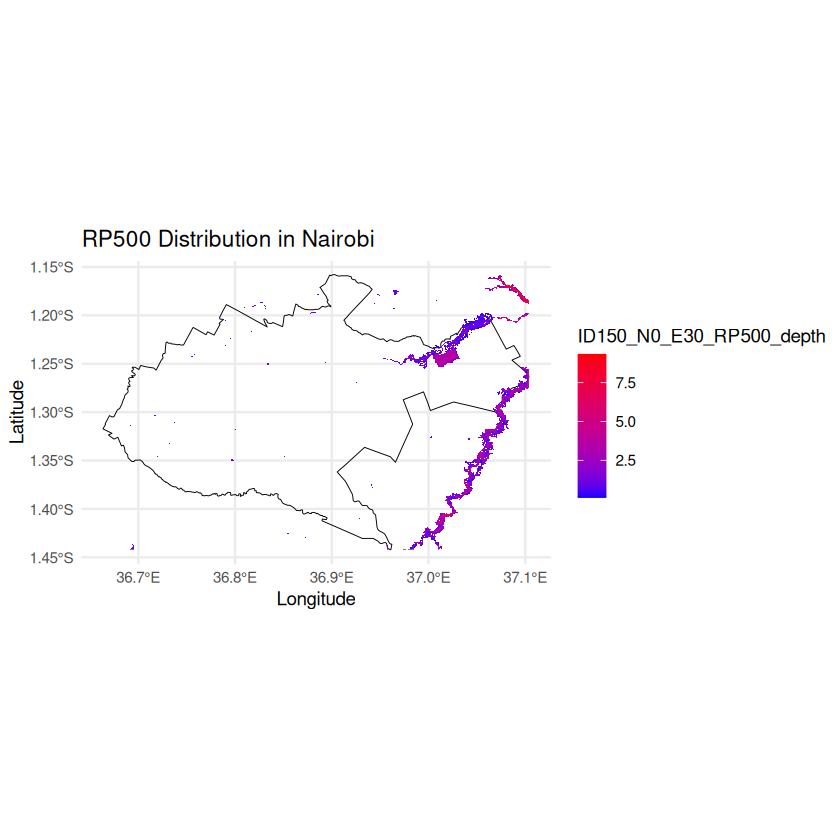

In [8]:
# DATASET 3: JRC GLOBAL RIVER FLOOD HAZARD
#500 M

# Load the population data from previously downloaded data
RP500 <- terra::rast("processed_data/RP500/ID150_N0_E30_RP500_depth.tif") 
RP500_crs <- crs(RP500)
cat("Pop CRS:\n", st_crs(RP500)$input, "\n\n")
print(RP500)

# Clip flood hazard data to AOI
RP500_clip <- crop(RP500, nairobi_gadm)


# Plot population distribution in Nairobi using ggplot
ggplot() +
  # Add region boundaries with black outlines
  geom_sf(data = nairobi_gadm, fill = NA, color = "black", size = 0.5) +
  # Add the raster layer directly
  geom_spatraster(data = RP500_clip) +  
  # Add a color scale for population values - blue to red
  scale_fill_gradient(name = "ID150_N0_E30_RP500_depth", 
                      low = "blue", 
                      high = "red", 
                      na.value = "transparent") +
  # Add labels and title
  labs(
    title = "RP500 Distribution in Nairobi",
    x = "Longitude",
    y = "Latitude"
  ) +
  # Use a clean theme
  theme_minimal() +
  # Ensure the map uses the correct aspect ratio
  coord_sf()

Warning message:
“[hist] a sample of 1% of the cells was used (of which 89% was NA)”


Warning message:
“[hist] a sample of 1% of the cells was used (of which 89% was NA)”


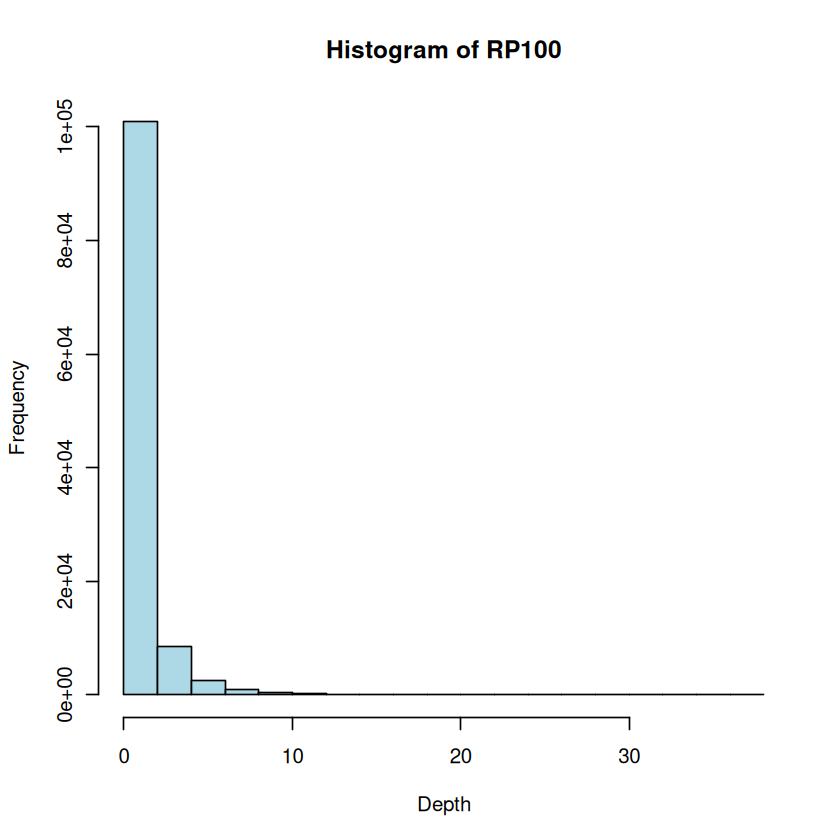

Warning message:
“[hist] a sample of 1% of the cells was used (of which 88% was NA)”


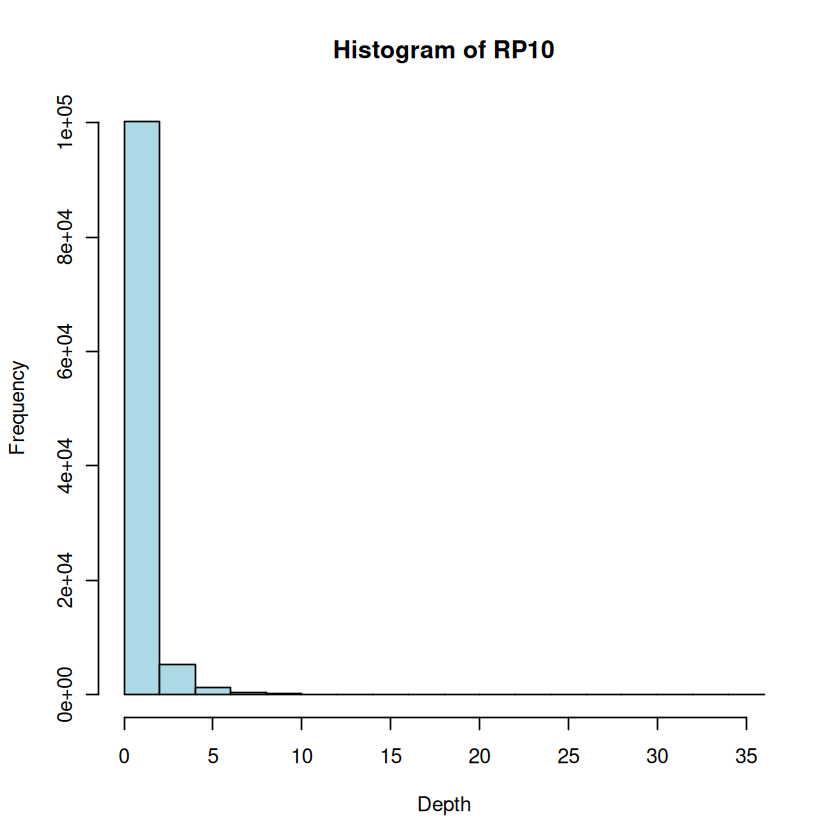

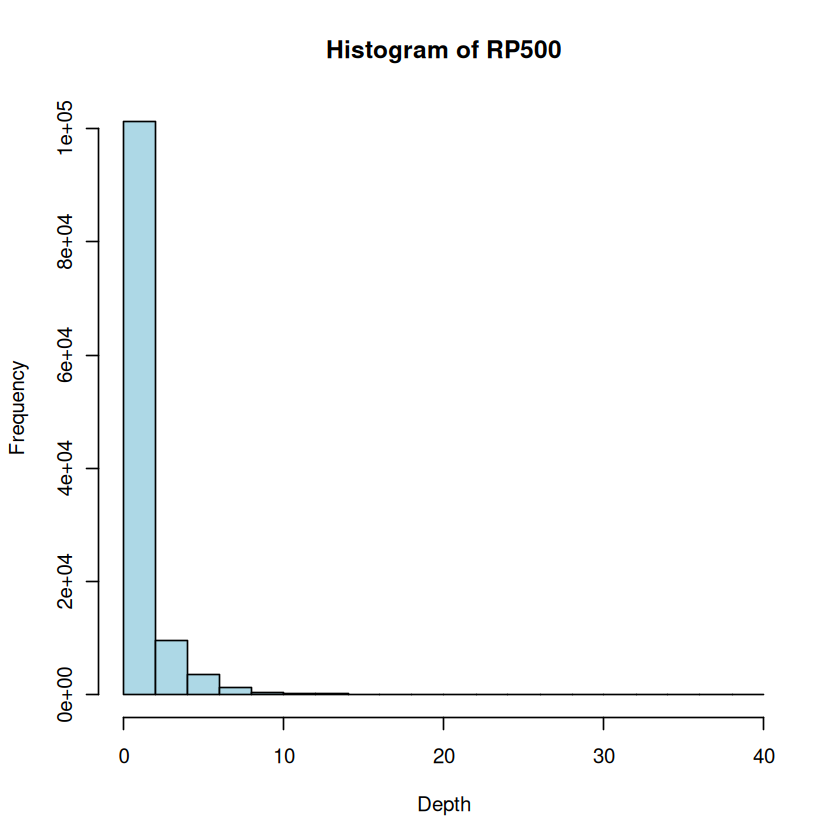

In [13]:
# Create a histogram to check the distribution of values
hist(RP100, main="Histogram of RP100", 
     xlab="Depth", col="lightblue", breaks=20)

# Create a histogram to check the distribution of values
hist(RP10, main="Histogram of RP10", 
     xlab="Depth", col="lightblue", breaks=20)

# Create a histogram to check the distribution of values
hist(RP500, main="Histogram of RP500", 
     xlab="Depth", col="lightblue", breaks=20)

While the above JRC's flood hazard maps provide valuable regional perspective, it is lacking the spatial and temporal resolution needed to capture granularity at the city scale.
To address that gap we are going to explore Microsoft AI's flood events dataset.


In [0]:
# DATASET 4: Download the parquet data from the repository

# --- Config ---
dir_path <- "/home/user/course-2-data-stewardship/module-7/pset-student/CRUM_Nairobi/data/raw_data"
file_name <- "S03E036-post-processing.parquet"
url <- "https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/resolve/main/S03/S03E036/S03E036-post-processing.parquet"

# --- Ensure the directory exists and is writable ---
if (!dir.exists(dir_path)) {
  stop(sprintf("Directory does not exist: %s", dir_path))
}
# Optional: check write permission by creating a tiny temp file
test_file <- file.path(dir_path, ".write_test")
tryCatch({
  writeLines("ok", test_file)
  unlink(test_file)
}, error = function(e) {
  stop(sprintf("No write permission in %s: %s", dir_path, e$message))
})

# --- Build absolute destination path ---
dest <- file.path(dir_path, file_name)
message(sprintf("Downloading to: %s", dest))

# --- Primary download: libcurl (cross-platform) ---
ok <- TRUE
tryCatch({
  utils::download.file(url, destfile = dest, mode = "wb", method = "libcurl")
}, error = function(e) {
  message(sprintf("libcurl download failed: %s", e$message))
  ok <<- FALSE
})

# --- Fallbacks if needed ---
if (!ok || !file.exists(dest) || (file.info(dest)$size %||% 0) == 0) {
  sysname <- tolower(Sys.info()[["sysname"]])

  if (sysname == "windows") {
    message("Trying Windows wininet fallback...")
    tryCatch({
      utils::download.file(url, destfile = dest, mode = "wb", method = "wininet")
      ok <- file.exists(dest) && file.info(dest)$size > 0
    }, error = function(e) message(sprintf("wininet failed: %s", e$message)))
  } else {
    message("Trying system curl fallback (Linux/macOS)...")
    cmd <- sprintf('curl -L "%s" -o "%s"', url, dest)
    system(cmd)
    ok <- file.exists(dest) && file.info(dest)$size > 0
  }
}

# --- Final check ---
if (!ok || !file.exists(dest) || file.info(dest)$size == 0) {
  stop("Download failed after fallbacks. Check network/proxy/SSL and try again.")
}

# --- Read the Parquet to verify ---
if (!requireNamespace("arrow", quietly = TRUE)) install.packages("arrow")
library(arrow)
library(dplyr)

df <- arrow::read_parquet(dest)
message("Parquet read OK. Preview:")
print(glimpse(df))

Given the large size of the original dataset and CoCalc’s memory limitations, the clipping and transformation of the data were performed in QGIS (clipping the dataset to Nairobi County and converting it from the original Parquet format to a shapefile) 
Now, let's load and explore the dataset.

Reading layer `ai4g-flood-dataset' from data source 
  `/home/user/course-2-data-stewardship/module-7/pset-student/CRUM_Nairobi/data/processed_data/ai4g-flood-dataset.geojson' 
  using driver `GeoJSON'
Simple feature collection with 51891 features and 15 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: 36.67542 ymin: -1.433578 xmax: 37.10191 ymax: -1.162271
Geodetic CRS:  WGS 84


Rows: 51,891
Columns: 16
$ year       <int> 2018, 2017, 2017, 2017, 2017, 2018, 2019, 2017, 2017, 2017,…
$ month      <int> 1, 1, 8, 1, 9, 2, 9, 8, 8, 1, 2, 8, 12, 12, 2, 9, 1, 1, 1, …
$ day        <int> 29, 16, 18, 16, 28, 19, 13, 18, 18, 16, 19, 18, 21, 21, 22,…
$ lat        <dbl> -1.433578, -1.433247, -1.433098, -1.433066, -1.433000, -1.4…
$ lon        <dbl> 36.94641, 36.95321, 36.95318, 36.95321, 36.95381, 36.95281,…
$ filename   <chr> "S1B_IW_GRDH_1SDV_20180129T031116_20180129T031139_009380_01…
$ land_cover <int> 20, 30, 30, 30, 30, 30, 30, 20, 20, 30, 30, 30, 30, 30, 20,…
$ dem_metric <dbl> 0.96, 1.76, 1.74, 1.74, 1.86, 1.88, 0.89, 1.37, 2.10, 1.69,…
$ dem_metr_1 <dbl> 5.23, 3.60, 3.60, 3.60, 4.06, 3.32, 3.07, 2.90, 4.16, 3.32,…
$ soil_moist <dbl> 2.2, 3.0, 5.7, 3.0, 5.3, 13.7, 2.8, 5.7, 5.7, 3.0, 13.7, 5.…
$ soil_moi_1 <dbl> -0.96, -0.84, -0.44, -0.84, -0.49, 0.76, -0.87, -0.44, -0.4…
$ soil_moi_2 <dbl> 3.5, 2.0, 1.0, 2.0, 1.0, 6.2, 1.0, 1.0, 1.0, 2.0, 6.2, 1.0,…
$ soil_moi_3 <d

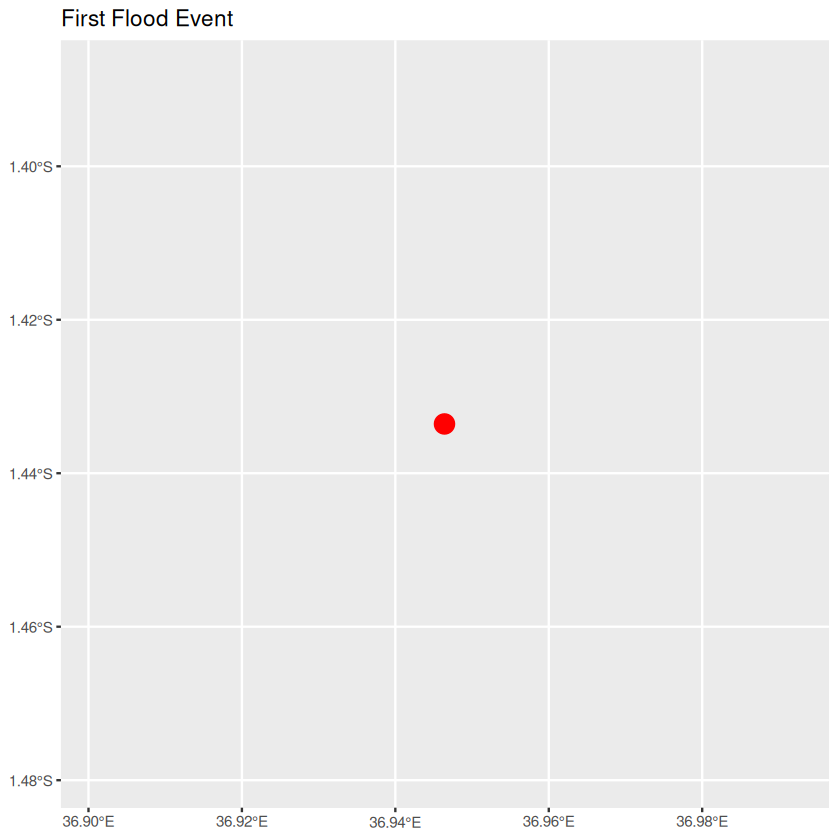

In [8]:
# Load the flood events dataset
floods <- st_read("processed_data/ai4g-flood-dataset.geojson")
print(glimpse(floods))

# Plot the first flood location
ggplot() +
  geom_sf(data = head(floods, 1), size = 5, color = "red") +
  ggtitle("First Flood Event")